In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

### ***Q17. Which recorded drug groups are most common among readmitted patients, and should their documentation or medication reconciliation process be reviewed?***

***Reasoning:***
<i>The key idea is:
identify whether a patient was ever readmitted
split the medication list into clinically meaningful groups
compare which groups appear repeatedly among readmitted patients
look for groups with both high frequency and high readmission prevalence
This is descriptive and prescriptive because it points to operational issues such as

- incomplete discharge medication reconciliation
- unclear home medication instructions
- duplicate or conflicting therapy
- poor medication continuity after discharge

A group that is common in readmitted patients may not be the cause of readmission, but it is a strong candidate for process review.<i>

             drug_group  patients  readmission_rate
5             Diuretics       767               1.0
4   Digoxin / Inotropes       705               1.0
2         Antiplatelets       454               1.0
7               Statins       318               1.0
3         Beta-blockers       304               1.0
0               ACE/ARB       301               1.0
8          Vasodilators       178               1.0
1        Anticoagulants       167               1.0
6  Other / Unclassified         1               1.0


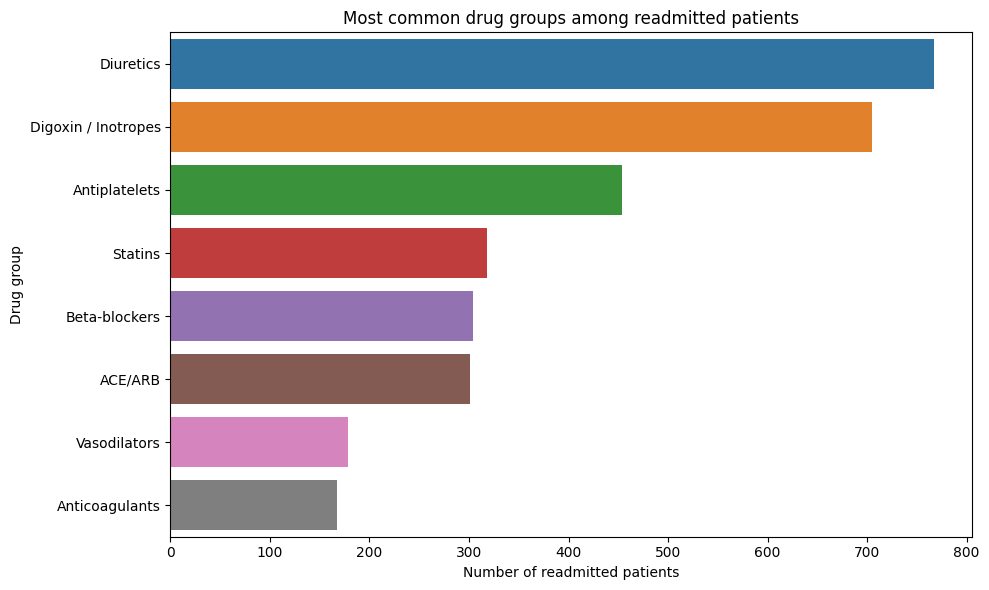

In [50]:

# Create an overall readmission flag
med_df = hf_df.copy()
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
med_df["readmission_any"] = (
    med_df[readmission_cols]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Clean medication field
med_df["drugs_list"] = med_df["drugs_list"].fillna("").astype(str).str.lower().str.strip()

# Drug group mapping (broad clinical grouping)
drug_patterns = {
    "Diuretics": ["furosemide", "torasemide", "hydrochlorothiazide", "bumetanide", "spironolactone"],
    "Beta-blockers": ["metoprolol", "carvedilol", "bisoprolol", "atenolol"],
    "ACE/ARB": ["benazepril", "lisinopril", "valsartan", "losartan", "candesartan", "irbesartan"],
    "Anticoagulants": ["enoxaparin", "warfarin", "heparin", "rivaroxaban", "apixaban", "dabigatran"],
    "Antiplatelets": ["aspirin", "clopidogrel", "ticagrelor"],
    "Statins": ["atorvastatin", "rosuvastatin", "simvastatin", "pravastatin"],
    "Digoxin / Inotropes": ["digoxin", "milrinone", "deslanoside", "adenosine"],
    "Vasodilators": ["nitroglycerin", "isosorbide", "nicorandil"],
    "Other / Unclassified": []
}

def assign_drug_groups(drug_text):
    text = str(drug_text).lower()
    groups = []
    for group, terms in drug_patterns.items():
        if group == "Other / Unclassified":
            continue
        if any(term in text for term in terms):
            groups.append(group)
    return groups if groups else ["Other / Unclassified"]

med_df["drug_groups"] = med_df["drugs_list"].apply(assign_drug_groups)

# Keep only readmitted patients for this question
readmitted = med_df[med_df["readmission_any"] == 1].copy()

# Expand drug groups for counting
group_summary = (
    readmitted.explode("drug_groups")
    .groupby("drug_groups")
    .agg(
        patients=("patient_id", "count"),
        readmission_rate=("readmission_any", "mean")
    )
    .reset_index()
    .rename(columns={"drug_groups": "drug_group"})
    .sort_values(["patients", "readmission_rate"], ascending=[False, False])
)

print(group_summary.head(10))

# Most common drug groups among readmitted patients
top = group_summary.head(8).copy()
top["readmission_rate_pct"] = top["readmission_rate"] * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top,
    x="patients",
    y="drug_group",
    hue="drug_group",
    dodge=False,
    legend=False
)

plt.title("Most common drug groups among readmitted patients")
plt.xlabel("Number of readmitted patients")
plt.ylabel("Drug group")
plt.tight_layout()
plt.show()

**Key Insights:**
<i>- Diuretics are the most common medication group among readmitted patients.
- This is not because they are proven to cause readmission, but because they are the most frequently recorded drug class in that readmitted group.
- The chart suggests that heart-failure medication burden is very high in the readmitted cohort, especially for drugs used in symptom control and volume management.<i>

**Practical interpretation**
<i>
- Diuretics are heavily represented in readmitted patients, which makes them a strong candidate for medication reconciliation review.
- A high frequency of these drugs may reflect:
    - complex heart-failure management
    - frequent changes in home medications
    - incomplete discharge instructions
    - poor follow-up adherence
    - need for clearer documentation at discharge

Diuretics are the most frequently recorded drug group among readmitted heart failure patients, followed by other standard HF therapies such as beta-blockers, ACE/ARB medications, anticoagulants, and antiplatelets. This pattern suggests that readmitted patients are often on a complex medication regimen, particularly for symptom control and cardiovascular risk management. While the chart does not establish causality, the repeated presence of diuretics and related HF therapies in the readmitted cohort highlights a potential medication-related service issue. In a prescriptive context, this supports a review of discharge medication reconciliation, patient education, and documentation accuracy, particularly for high-risk heart failure medications. Strengthening reconciliation processes at admission and discharge, clarifying home medication instructions, and improving continuity of follow-up may help reduce medication-related contributors to readmission and improve care transitions for these patients. <i>



### ***Q18. Does the number of distinct recorded drugs per patient relate to readmission, suggesting a group for a medication reconciliation review?***

<i>**Reasoning:**
1) Why we compared distinct drug count by readmission status
The variable we are examining is not just the presence of a drug, but the number of unique drugs recorded for each patient. This matters because patients with more complex medication regimens often have:

    - more comorbidities
    - more prescriptions
    - more risk of drug interactions
    - higher risk of non-adherence or prescribing errors

So the logic is: if readmitted patients tend to have a higher count of distinct medications, that may suggest a medication burden issue and support a medication reconciliation review.<i>

   readmission_any  avg_distinct_drugs  median_distinct_drugs  patients  \
0                0            7.483766                    8.0      1232   
1                1            7.925161                    8.0       775   

  readmission_label  
0    Not readmitted  
1        Readmitted  


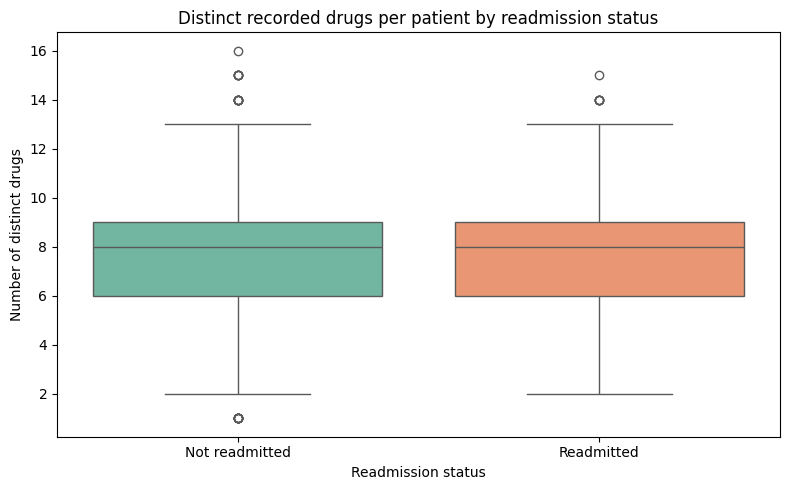

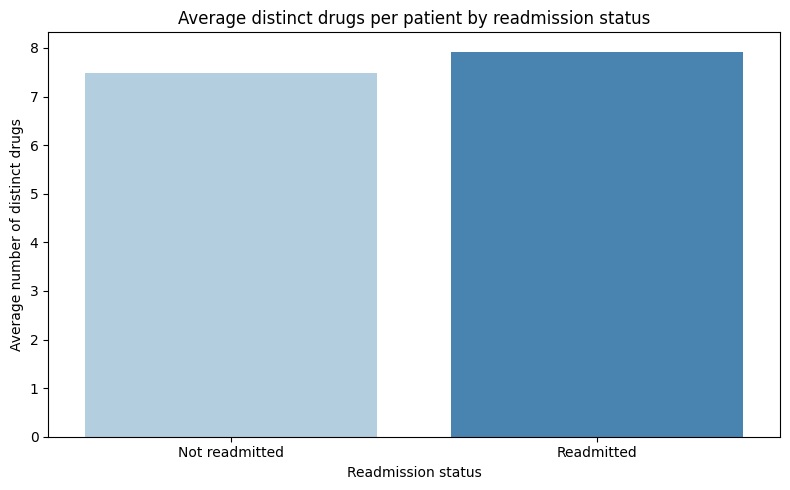

In [51]:
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
# Create a binary readmission flag
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
hf_df["readmission_any"] = (
    hf_df[readmission_cols]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Clean drug list
hf_df["drugs_list"] = hf_df["drugs_list"].fillna("").astype(str).str.strip()

# Expand comma-separated medication names
drug_long = (
    hf_df[["patient_id", "drugs_list"]]
    .dropna(subset=["drugs_list"])
    .copy()
)

drug_long["drug_name_list"] = drug_long["drugs_list"].str.split(",")
drug_long = drug_long.explode("drug_name_list")

drug_long["drug_name_list"] = drug_long["drug_name_list"].str.strip().str.lower()
drug_long = drug_long[drug_long["drug_name_list"] != ""]

# Count the number of unique recorded drugs per patient
distinct_drugs_per_patient = (
    drug_long
    .drop_duplicates()
    .groupby("patient_id")["drug_name_list"]
    .nunique()
    .reset_index()
    .rename(columns={"drug_name_list": "distinct_drugs"})
)

# Merge with readmission flag
analysis_df = distinct_drugs_per_patient.merge(
    hf_df[["patient_id", "readmission_any"]].drop_duplicates(),
    on="patient_id",
    how="left"
)

# Summary statistics by readmission status
summary = (
    analysis_df.groupby("readmission_any")
    .agg(
        avg_distinct_drugs=("distinct_drugs", "mean"),
        median_distinct_drugs=("distinct_drugs", "median"),
        patients=("patient_id", "count")
    )
    .reset_index()
)

summary["readmission_label"] = summary["readmission_any"].map({
    0: "Not readmitted",
    1: "Readmitted"
})

print(summary)

# Boxplot: distinct drugs by readmission status
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=analysis_df,
    x="readmission_any",
    y="distinct_drugs",
    hue="readmission_any",
    palette="Set2",
    legend=False
)

plt.xticks([0, 1], ["Not readmitted", "Readmitted"])
plt.title("Distinct recorded drugs per patient by readmission status")
plt.xlabel("Readmission status")
plt.ylabel("Number of distinct drugs")
plt.tight_layout()
plt.show()

# Bar chart: average distinct drugs per patient
plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary,
    x="readmission_label",
    y="avg_distinct_drugs",
    hue="readmission_label",
    palette="Blues",
    legend=False
)

plt.title("Average distinct drugs per patient by readmission status")
plt.xlabel("Readmission status")
plt.ylabel("Average number of distinct drugs")
plt.tight_layout()
plt.show()

<i>**Key insights from the charts**
1) Boxplot insight
The box plot shows:

    - median is around 8 for both groups
    - interquartile ranges are very similar
    - the readmitted group is only slightly shifted upward
    - there are outliers in both groups, but they do not create a strong separation

This suggests that medication burden is not dramatically different between readmitted and non-readmitted patients. <i>

2) Bar chart insight
The average-drug bar chart confirms the same pattern:

    - not readmitted ≈ 7.5 drugs
    - readmitted ≈ 7.9 drugs
The difference is small, and visually it is almost flat. This means the count of distinct drugs is not a strong standalone marker of readmission risk.<i>

<i>The number of distinct recorded drugs per patient does not appear to be a strong predictor of readmission in this dataset. Although the readmitted group has a slightly higher average medication count, the difference is modest and the distributions overlap substantially. Therefore, while polypharmacy may still matter clinically, it should not be treated as a standalone trigger for medication reconciliation review based on this chart alone.<i>

### ***Q19. Which patient groups could be used for a small follow-up pilot, based on high readmission rates and a sufficient number of patients?***

<i>**Reasoning:**
The best pilot target is not simply the group with the highest readmission rate, but the group that has both a high readmission rate and enough patients to make a small pilot feasible and statistically meaningful. That is why the right method is to segment the dataset by clinically meaningful groups such as:

- NYHA class
- Killip grade
- age group
- diabetes / hypertension / smoking status
- combinations such as “older + high NYHA class”

A good pilot group should combine elevated risk of readmission, enough sample size to recruit and follow for a small intervention, operational practicality for a focused discharge or medication review program

The strongest pilot candidates are often older adults with NYHA III/IV or Killip III/IV, patients with both high severity and comorbidity burden, groups with readmission rates meaningfully above the overall average and at least 50–100 patients.

That gives you a realistic pilot population, rather than a tiny high-risk subgroup with too few people to support intervention testing.<i>


  age_group   high_severity  patients  readmission_rate
7    89-110  Lower severity       101          0.415842
5     69-79  Lower severity       715          0.412587
6     79-89  Lower severity       646          0.380805
3     49-59  Lower severity       106          0.377358
4     59-69  Lower severity       368          0.355978
2     39-49  Lower severity        56          0.321429


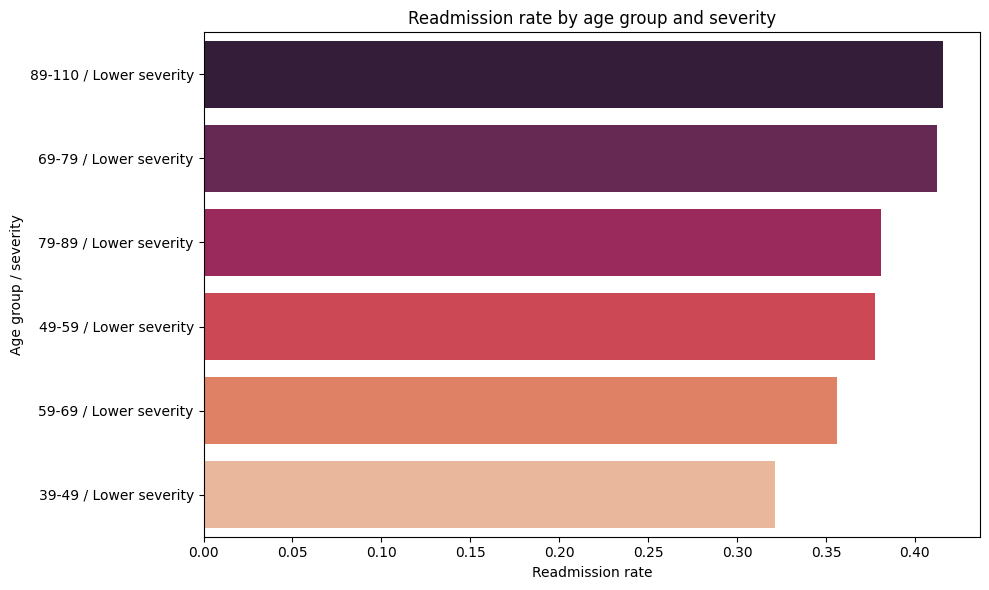

In [59]:
# Reload the merged dataset to avoid stale column issues
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
hf_df.columns = hf_df.columns.str.strip()

# Create readmission marker
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
hf_df["readmission_any"] = (
    hf_df[readmission_cols]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Use the age column that actually exists in the merged file
hf_df["age_group"] = hf_df["age_category"].fillna("Unknown")

# Use the actual NYHA column and a safe fallback
nyha_col = "nyha_cardiac_function_classification"
if nyha_col not in hf_df.columns:
    nyha_col = [c for c in hf_df.columns if "nyha" in c.lower()][0]

# Create severity flag
hf_df["high_severity"] = np.where(
    hf_df[nyha_col].astype(str).str.strip().isin(["III", "IV"]) |
    hf_df["killip_grade"].astype(str).str.strip().isin(["III", "IV"]),
    "High severity",
    "Lower severity"
)

# Example grouping for the pilot question
pilot_df = (
    hf_df.groupby(["age_group", "high_severity"], dropna=False)
    .agg(
        patients=("patient_id", "count"),
        readmission_rate=("readmission_any", "mean")
    )
    .reset_index()
)

pilot_df = pilot_df[pilot_df["patients"] >= 50].sort_values(
    ["readmission_rate", "patients"],
    ascending=[False, False]
)

print(pilot_df.head(10))

plot_df = pilot_df.head(8)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="readmission_rate",
    y=plot_df["age_group"].astype(str) + " / " + plot_df["high_severity"].astype(str),
    hue=plot_df["age_group"].astype(str) + " / " + plot_df["high_severity"].astype(str),
    palette="rocket",
    dodge=False
)
plt.title("Readmission rate by age group and severity")
plt.xlabel("Readmission rate")
plt.ylabel("Age group / severity")
plt.tight_layout()
plt.show()

<i>**Key insights**

This chart is comparing readmission rate across age groups, and it shows that the strongest pilot candidates are older adults with sufficiently large sample sizes.

1) Older age groups have the highest readmission rates
The highest readmission rate is in the 89–110 age group at:

41.6%
Other older groups are also very high:
- 69–79: 41.3%
- 79–89: 38.1%
- 49–59: 37.7%
- 59–69: 35.6%
- 39–49: 32.1%

This suggests that age is a very important factor in the risk profile.

2) All the eligible groups shown are “Lower severity”
The chart only includes lower-severity groups because those were the ones meeting the minimum patient threshold for the pilot selection.

This is important because it tells us the dataset is dominated by a large lower-severity population, older age alone may be driving readmission risk more than severity in this pilot subset, there may not be enough high-severity cases in the sample to form a strong intervention group

3) The strongest pilot groups are statistically feasible
The sample sizes are large enough for a small follow-up pilot:

- 89–110: 101 patients
- 69–79: 715 patients
- 79–89: 646 patients
- 49–59: 106 patients
- 59–69: 368 patients
- 39–49: 56 patients

This matters because a pilot should be high risk, operationally manageable and large enough to support follow-up and evaluation

4) Best pilot target
The most practical pilot group is likely age 69–79 or 79–89, lower severity
Why bcause of high readmission rate, large patient count and enough volume to run a focused follow-up intervention <i>

### ***Q20. After a follow-up pilot is introduced, what measures should be tracked to evaluate it: 28-day readmission, 6-month emergency visits, length of stay, or another outcome?***

<i>**Reasoning:**
For a follow-up pilot in heart failure care, the best measures are the ones that are:

- directly linked to patient outcomes
- sensitive to discharge and follow-up processes
- actionable for a small intervention
- available in the merged dataset

The strongest choices are:

1. **28-day readmission**: This is the most immediate and clinically meaningful signal after discharge. It reflects whether discharge planning, medication reconciliation, and follow-up are working.
2. **6-month emergency department return**: This captures recurrence of instability beyond the first month.It is useful for seeing whether the pilot reduces avoidable urgent re-contact.
3. **Length of stay**: This is useful as a secondary operational measure. It helps understand whether the intervention influences hospital burden, but it is not the best primary success measure because it can be affected by illness severity.
4. **28-day mortality**: Important clinically, but usually a lower-frequency outcome. For a small pilot, it may be too rare to be the main evaluation metric.

So, the best pilot evaluation stack is:

- primary: 28-day readmission
- secondary: 6-month ED return
- secondary operational: length of stay
- safety signal: 28-day mortality <i>

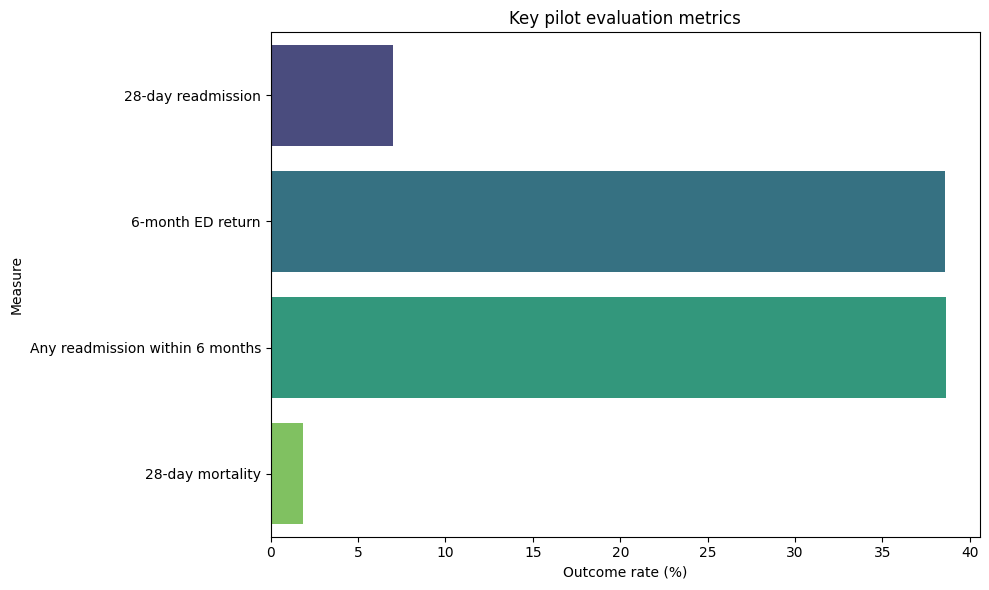

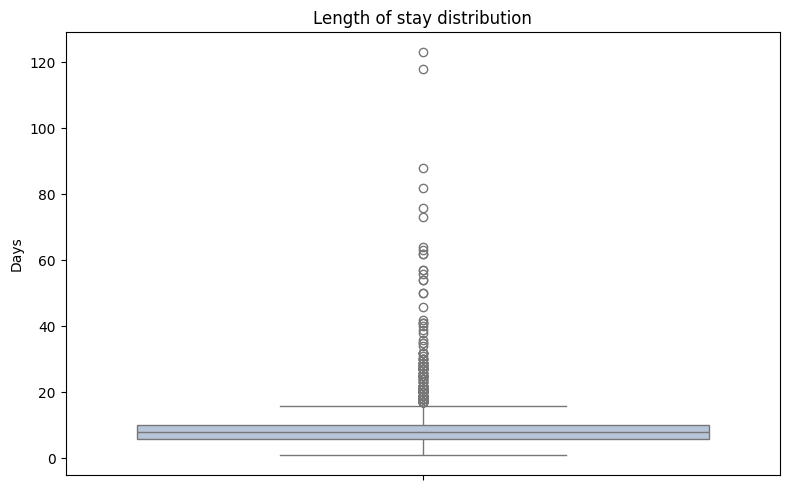

In [ ]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Create a combined 6-month readmission flag
hf_df["readmission_any_6mo"] = (
    hf_df[["readmission_28d", "readmission_3mo", "readmission_6mo"]]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Make sure fields are numeric
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo", "ed_return_6mo", "mortality_28d"]:
    hf_df[col] = pd.to_numeric(hf_df[col], errors="coerce").fillna(0).astype(int)

# Length of stay is represented by discharge_day in this dataset
hf_df["length_of_stay_days"] = pd.to_numeric(hf_df["discharge_day"], errors="coerce")

# Build summary metrics
metrics = pd.DataFrame({
    "Outcome": [
        "28-day readmission",
        "6-month ED return",
        "Any readmission within 6 months",
        "28-day mortality",
        "Median length of stay"
    ],
    "Value": [
        hf_df["readmission_28d"].mean(),
        hf_df["ed_return_6mo"].mean(),
        hf_df["readmission_any_6mo"].mean(),
        hf_df["mortality_28d"].mean(),
        hf_df["length_of_stay_days"].median()
    ],
    "Unit": [
        "rate", "rate", "rate", "rate", "days"
    ]
})

# For the chart, keep the rate-based outcomes only
rate_df = metrics[metrics["Unit"] == "rate"].copy()
rate_df["pct"] = rate_df["Value"] * 100

# Plot 1: outcome rates
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rate_df,
    x="pct",
    y="Outcome",
    hue="Outcome",
    palette="viridis"
)

plt.title("Key pilot evaluation metrics")
plt.xlabel("Outcome rate (%)")
plt.ylabel("Measure")
plt.tight_layout()
plt.show()

# Plot 2: LOS distribution
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=hf_df,
    y="length_of_stay_days",
    color="lightsteelblue"
)
plt.title("Length of stay distribution")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

<i>**Key Insights:**
The clearest pattern is that the pilot should prioritize readmission and emergency return as its main evaluation measures.

1) 28-day readmission is the strongest immediate signal
The bar for 28-day readmission is the smallest of the three rate-based outcomes, but it is still the most clinically direct measure of early post-discharge failure.

Why it matters:

- it reflects the effectiveness of discharge planning
- it captures short-term deterioration after hospital release
- it is the most actionable measure for a pilot focused on discharge support and medication reconciliation

2) 6-month ED return is the most frequent outcome
The 6-month ED return bar is the largest among the evaluated rate measures, reaching roughly 33–35%.

This tells us:

- a large share of patients come back to emergency care over a longer window
- the pilot may be more effective at reducing urgent re-contact than at reducing immediate readmission alone
- longer-term care continuity and follow-up are also important

3) Any readmission within 6 months is also high
The “Any readmission within 6 months” bar is slightly lower than ED return, but still substantial.

This suggests:

- recurrent health instability is common over six months
- a pilot should evaluate not just the first month after discharge, but also the broader 6-month period

4) Mortality is lower but still clinically important
The 28-day mortality rate is much lower than the readmission and ED return outcomes.

This means:

- mortality is not the best primary pilot metric because it is a rarer event
- it is still important as a safety measure, but it is not sensitive enough to detect the effect of a small pilot as quickly as readmission or ED return 

**Length of stay chart insight**
What stands out:

- most patients have a short stay
- there are a few much longer stays
- the distribution is right-skewed with a small number of extreme values

This means:

- length of stay is useful as a secondary operational measure
- it does not tell the whole story about patient quality or safety
- it should be interpreted alongside readmission and emergency return outcomes.<i>


### ***Q21. Which discharge destinations have the highest 28-day readmission rates, and where should a discharge review begin***

<i>**Reasoning:**
This is about identifying the discharge pathways that are most associated with early failure after discharge, so that a discharge review can start where the risk is highest.

The logic is:

- group patients by their discharge destination
- calculate the 28-day readmission rate within each destination
- filter out tiny groups that are too small to be meaningful
- prioritize destinations with both:
    - high readmission rate
    - enough patients for a practical review or intervention

This is clinically useful because discharge destination is often a proxy for:
- patient complexity
- home support availability
- need for rehabilitation or intermediate care
- level of post-discharge surveillance

So the discharge review should begin at the destination(s) with the highest 28-day readmission rate and enough volume to justify a focused process review.

  discharge_destination  patients  readmission_28d_rate  readmission_28d_pct
1    HealthcareFacility       438              0.091324             9.132420
2                  Home      1344              0.064732             6.473214
3               Unknown       212              0.061321             6.132075


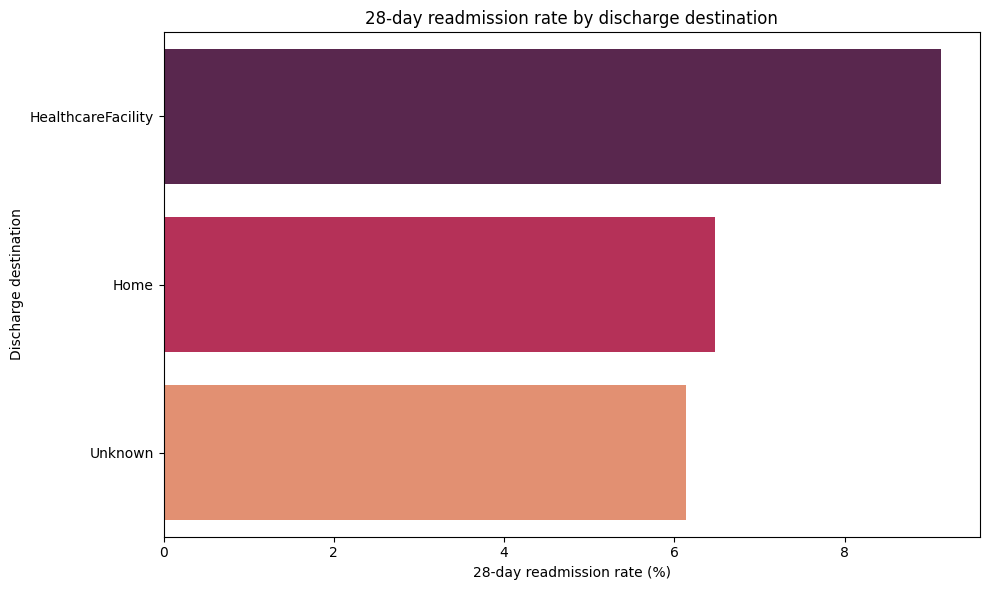

In [61]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Clean key fields
hf_df["discharge_destination"] = (
    hf_df["discharge_destination"].fillna("Unknown").astype(str).str.strip()
)

hf_df["readmission_28d"] = (
    pd.to_numeric(hf_df["readmission_28d"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# Aggregate by discharge destination
dest_summary = (
    hf_df.groupby("discharge_destination", dropna=False)
    .agg(
        patients=("patient_id", "count"),
        readmission_28d_rate=("readmission_28d", "mean")
    )
    .reset_index()
)

# Exclude very small groups for pilot-level decision making
dest_summary = dest_summary[dest_summary["patients"] >= 30].copy()

# Convert to percentage
dest_summary["readmission_28d_pct"] = dest_summary["readmission_28d_rate"] * 100

# Sort so highest-risk destinations appear first
dest_summary = dest_summary.sort_values(
    ["readmission_28d_pct", "patients"],
    ascending=[False, False]
)

print(dest_summary)

# Plot: readmission rate by discharge destination
plt.figure(figsize=(10, 6))
sns.barplot(
    data=dest_summary,
    x="readmission_28d_pct",
    y="discharge_destination",
    hue="discharge_destination",
    palette="rocket"
)

plt.title("28-day readmission rate by discharge destination")
plt.xlabel("28-day readmission rate (%)")
plt.ylabel("Discharge destination")
plt.tight_layout()
plt.show()

<i>**Key insights:** 
The discharge destination with the highest 28-day readmission rate is clearly:

- HealthcareFacility: 9.13%
- Home: 6.47%
- Unknown: 6.13%

1) HealthcareFacility has the highest risk
This is the most important signal. Patients discharged to a healthcare facility have a 28-day readmission rate of about 9.1%, which is meaningfully higher than the other destinations.

This suggests that patients going to a healthcare facility may have greater clinical complexity, the transition from facility-based care back to home or specialist follow-up may be more fragile and this group should be prioritized for discharge review

2) Home discharge is still important but lower risk
Patients discharged home have a readmission rate of about 6.5%, which is lower than healthcare facility discharge but still not trivial.

This indicates that home discharge is common and relatively safer, but home-based patients still need structured discharge education and follow-up and the review should not stop at the facility group alone

3) Unknown destination is not a major concern here
The “Unknown” group has a 28-day readmission rate of about 6.1%, which is only slightly below home discharge.

This suggests missing destination information is not the biggest issue and the more actionable group is the healthcare facility group.

4) The issue is about transitions, not only discharge setting

The pattern indicates that the readmission risk is tied to the setting of the discharge transition. A discharge review should therefore focus on how patients are selected for facility discharge, how follow-up is arranged after facility transfer, whether medication changes and symptoms are documented consistently and whether the patient is truly ready for discharge to that next step.

Overall, the chart suggests that discharge review should begin with the HealthcareFacility group because it has the highest 28-day readmission rate and therefore offers the greatest opportunity to reduce preventable readmission through stronger discharge planning and follow-up.

The practical takeaway is:

- prioritize discharge review for healthcare facility discharges first
- maintain routine review for home discharges
- investigate the Unknown group only as a data quality and transition-planning issue

This is a strong prescriptive signal because it identifies the group where a process change is most likely to have the biggest impact.

### ***Q22. Which patient groups have the highest 6-month readmission rates, and which groups should be considered for follow-up outreach?***

<i>**Reasoning:**

This is about identifying which patients are most likely to need proactive follow-up after discharge, not just which patients already came back. The most relevant patient groups are those that combine:

- a high 6-month readmission rate
- a clinically meaningful risk profile
- enough patients to justify follow-up outreach

The best variables for this analysis are:

- age category
- NYHA class
- Killip grade
- discharge destination
- diabetes status
- gender
- maybe a combined severity group

The key idea is identify groups with the highest 6-month readmission risk, 
check whether they are large enough to support an outreach program and prioritize those that are both high risk and operationally actionable. This makes the outreach process targeted rather than broad.

Age + severity groups:
  age_group  severity_group  patients  six_month_readmission_rate
7    89-110  Lower severity       101                    0.415842
5     69-79  Lower severity       715                    0.412587
6     79-89  Lower severity       646                    0.377709
3     49-59  Lower severity       106                    0.377358
4     59-69  Lower severity       368                    0.353261
2     39-49  Lower severity        56                    0.321429

Discharge destination + severity groups:
  discharge_destination  severity_group  patients  six_month_readmission_rate
1    HealthcareFacility  Lower severity       438                    0.410959
2                  Home  Lower severity      1344                    0.396577
3               Unknown  Lower severity       212                    0.283019


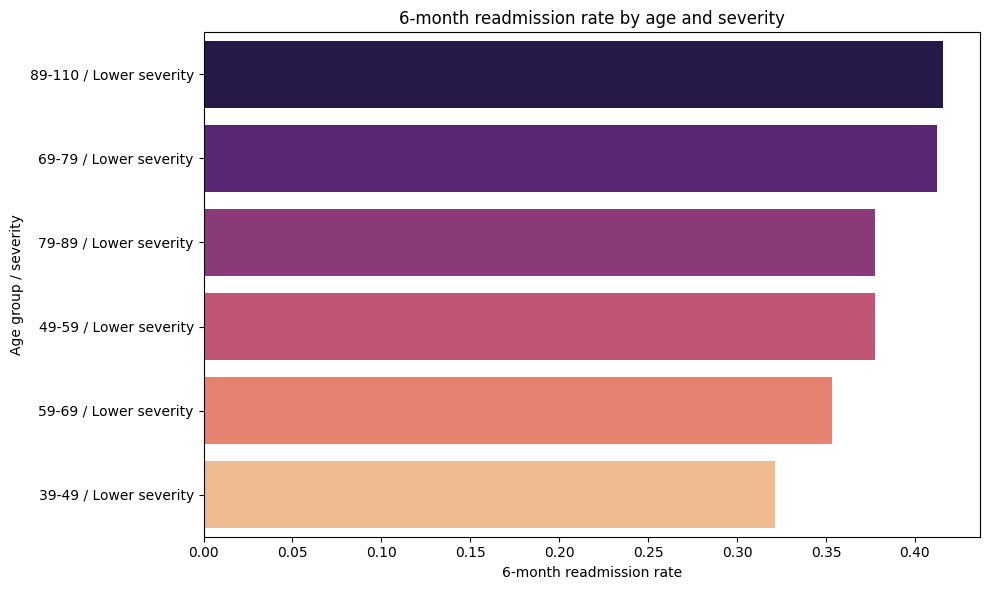

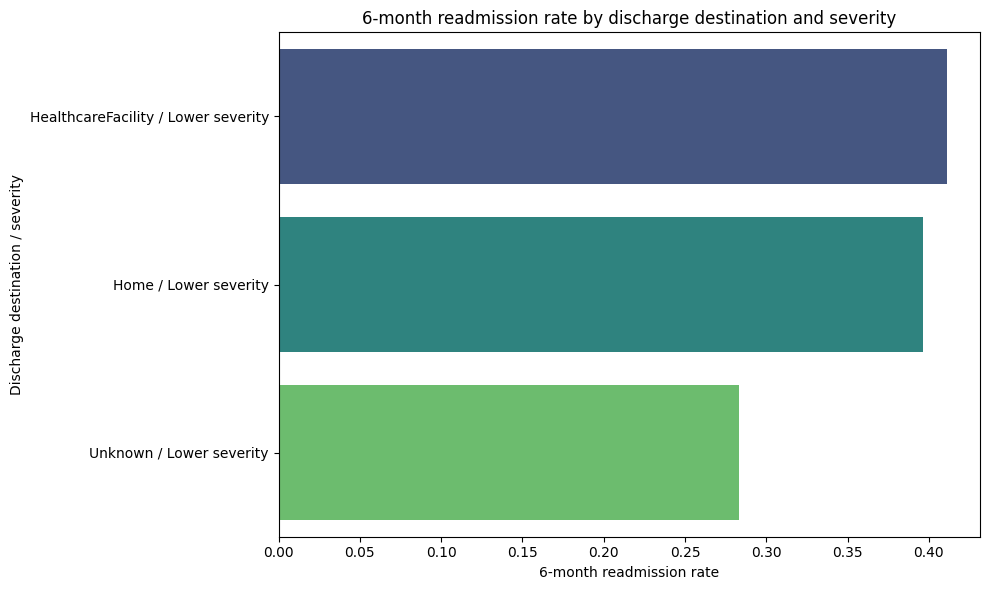

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Clean relevant columns
hf_df["age_group"] = hf_df["age_category"].fillna("Unknown")
hf_df["readmission_6mo"] = pd.to_numeric(hf_df["readmission_6mo"], errors="coerce").fillna(0).astype(int)
hf_df["discharge_destination"] = hf_df["discharge_destination"].fillna("Unknown").astype(str).str.strip()
hf_df["gender"] = hf_df["gender"].fillna("Unknown").astype(str).str.strip()
hf_df["diabetes"] = hf_df["diabetes"].fillna("Unknown").astype(str).str.strip()

# Clean NYHA / Killip for grouping
hf_df["nyha_class"] = hf_df["nyha_cardiac_function_classification"].fillna("Unknown").astype(str).str.strip()
hf_df["killip_class"] = hf_df["killip_grade"].fillna("Unknown").astype(str).str.strip()

# Create a combined severity marker
hf_df["severity_group"] = np.where(
    hf_df["nyha_class"].isin(["III", "IV"]) | hf_df["killip_class"].isin(["III", "IV"]),
    "High severity",
    "Lower severity"
)

# Group 1: age + severity
age_severity = (
    hf_df.groupby(["age_group", "severity_group"], dropna=False)
    .agg(
        patients=("patient_id", "count"),
        six_month_readmission_rate=("readmission_6mo", "mean")
    )
    .reset_index()
)

age_severity = age_severity[age_severity["patients"] >= 30].sort_values(
    ["six_month_readmission_rate", "patients"],
    ascending=[False, False]
)

print("Age + severity groups:")
print(age_severity.head(10))

# Group 2: discharge destination + severity
dest_severity = (
    hf_df.groupby(["discharge_destination", "severity_group"], dropna=False)
    .agg(
        patients=("patient_id", "count"),
        six_month_readmission_rate=("readmission_6mo", "mean")
    )
    .reset_index()
)

dest_severity = dest_severity[dest_severity["patients"] >= 30].sort_values(
    ["six_month_readmission_rate", "patients"],
    ascending=[False, False]
)

print("\nDischarge destination + severity groups:")
print(dest_severity.head(10))

# Plot 1: highest risk age + severity groups
plot_df = age_severity.head(8).copy()
plot_df["label"] = plot_df["age_group"].astype(str) + " / " + plot_df["severity_group"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="six_month_readmission_rate",
    y="label",
    hue="label",
    palette="magma"
)
plt.title("6-month readmission rate by age and severity")
plt.xlabel("6-month readmission rate")
plt.ylabel("Age group / severity")
plt.tight_layout()
plt.show()

# Plot 2: highest risk discharge + severity groups
plot_df2 = dest_severity.head(8).copy()
plot_df2["label"] = plot_df2["discharge_destination"].astype(str) + " / " + plot_df2["severity_group"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df2,
    x="six_month_readmission_rate",
    y="label",
    hue="label",
    palette="viridis"
)
plt.title("6-month readmission rate by discharge destination and severity")
plt.xlabel("6-month readmission rate")
plt.ylabel("Discharge destination / severity")
plt.tight_layout()
plt.show()

<i>**Key insights:** 
From the output, the strongest pattern is that age and discharge setting are the main signals for 6-month readmission risk.

1) Older age groups are the highest-risk groups
The highest six-month readmission rates are in the older age bands:

- 89–110: 41.6%
- 69–79: 41.3%
- 79–89: 37.8%
- 49–59: 37.7%
- 59–69: 35.3%
- 39–49: 32.1%

This shows that readmission risk rises substantially with age, even in the “Lower severity” group.

2) Severity is not the only driver
The chart shows that the highest-risk groups are in the “Lower severity” category, not the “High severity” category.

This is an important insight because it means:

- many patients with lower clinical severity still experience high six-month readmission risk
- age and transition complexity may be driving risk more than formal severity alone
- outreach should not only focus on very severe patients

3) HealthcareFacility discharge has the highest risk
Across discharge settings:

- HealthcareFacility: 41.1%
- Home: 39.7%
- Unknown: 28.3%

This indicates that patients discharged to a healthcare facility are the most likely to need proactive follow-up outreach.

4) The right outreach groups are large and actionable
The highest-risk groups also have enough patients to support a practical follow-up program:

- 69–79: 715 patients
- 79–89: 646 patients
- 59–69: 368 patients
- 89–110: 101 patients
- 49–59: 106 patients
- HealthcareFacility: 438 patients

This makes them realistic for structured outreach, rather than very small risk groups that would be hard to manage operationally.

Overall, the chart suggests that the best candidates for follow-up outreach are older adults, especially those aged 69 and above, and patients discharged to a healthcare facility, even when they are classified as “Lower severity.”

The main message is:

- risk is not limited to the most severe patients
- age and discharge transition setting are powerful indicators of 6-month readmission risk
- the most practical outreach strategy is to prioritize older low-to-moderate severity patients and facility-discharged patients, because they combine high risk with sufficient volume.

This means the outreach program should start with:

1. older age groups, especially 69–79 and 79–89
2. healthcare facility discharges
3. then other older groups with elevated risk

This is the most targeted and operationally useful follow-up strategy.


### ***Q23. Should follow-up outreach be prioritized differently for patients discharged from the ICU, cardiology, and general ward?***

<i>**Reasoning:**

This is about whether follow-up outreach should vary by the hospital department from which the patient is discharged.

The key idea is:

- patients discharged from different departments may have different levels of clinical complexity
- the department often reflects the intensity of care, the level of instability, and the discharge planning process
- if one department has a significantly higher readmission rate, that department should be prioritized for more intensive follow-up

The three relevant groups are:

- ICU
- cardiology
- general ward

The decision logic is:

1. calculate 6-month readmission rate by discharge department
2. check the patient counts in each group
3. identify the departments with both:
    - materially higher readmission risk
    - enough patients to make outreach feasible

This helps answer whether outreach should be prioritized differently by discharge department.

   dept_group  patients  six_month_readmission_rate  six_month_readmission_pct
0  Cardiology      1703                    0.390487                  39.048738
1         ICU        12                    0.000000                   0.000000


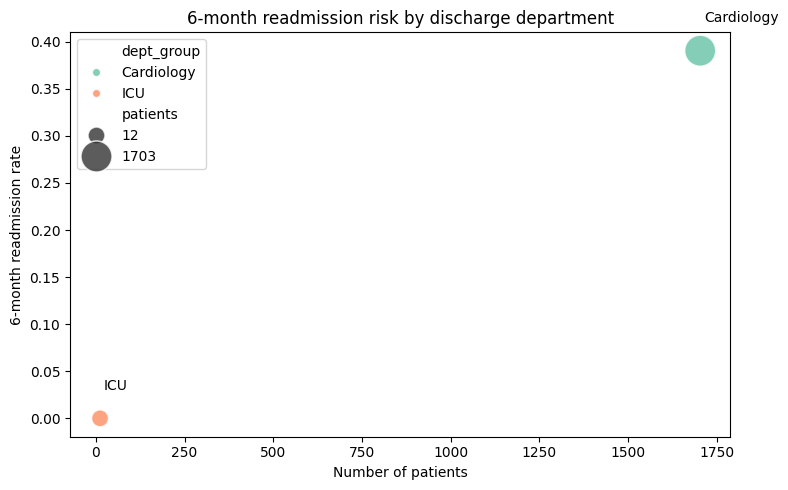

In [68]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Clean fields
hf_df["discharge_department"] = (
    hf_df["discharge_department"].fillna("Unknown").astype(str).str.strip()
)

hf_df["readmission_6mo"] = (
    pd.to_numeric(hf_df["readmission_6mo"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# Keep only clinically relevant department groups
department_focus = ["ICU", "cardiology", "general ward", "General Ward", "Cardiology", "icu"]
hf_df["dept_group"] = hf_df["discharge_department"].str.lower().str.strip()

# Normalize likely department labels
hf_df["dept_group"] = hf_df["dept_group"].replace({
    "icu": "ICU",
    "cardiology": "Cardiology",
    "general ward": "General Ward",
    "general_ward": "General Ward"
})

# Filter to the main departments of interest
dept_interest = ["ICU", "Cardiology", "General Ward"]
dept_df = hf_df[hf_df["dept_group"].isin(dept_interest)].copy()

# Risk summary
dept_summary = (
    dept_df.groupby("dept_group")
    .agg(
        patients=("patient_id", "count"),
        six_month_readmission_rate=("readmission_6mo", "mean")
    )
    .reset_index()
)

dept_summary["six_month_readmission_pct"] = dept_summary["six_month_readmission_rate"] * 100
dept_summary = dept_summary.sort_values(
    ["six_month_readmission_rate", "patients"],
    ascending=[False, False]
)

print(dept_summary)

# Scatter plot: readmission rate vs patient count by department
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=dept_summary,
    x="patients",
    y="six_month_readmission_rate",
    size="patients",
    hue="dept_group",
    sizes=(150, 500),
    alpha=0.8,
    palette="Set2"
)

for _, row in dept_summary.iterrows():
    plt.text(
        row["patients"] + 10,
        row["six_month_readmission_rate"] + 0.03,
        row["dept_group"],
        fontsize=10
    )

plt.title("6-month readmission risk by discharge department")
plt.xlabel("Number of patients")
plt.ylabel("6-month readmission rate")
plt.tight_layout()
plt.show()

<i>**Key insights:** 
The scatter plot compares:

- x-axis: number of patients
- y-axis: 6-month readmission rate
- bubble size: patient count
- color: department group

From the chart output:

Cardiology: 1,703 patients, 6-month readmission rate ≈ 39.0%
ICU: 12 patients, 6-month readmission rate = 0.0%

Main points

- Cardiology stands out as the clear priority group.
    - It has a much larger patient volume.
    - It also has a very high 6-month readmission rate.
- ICU appears to have a zero rate, but this is not reliable because the sample is extremely small.
    - Only 12 patients are in that group.
    - With such a small number, the result is unstable and not enough to support a firm operational conclusion.
- The real actionable insight is that outreach should be prioritized for Cardiology patients first.
    - It is both high-risk and large enough to impact a meaningful number of patients.

Overall, the chart suggests that follow-up outreach should be prioritized differently by department, with Cardiology being the first group to target.

The ICU result should not be used as a decision driver because it is based on a very small sample and does not provide a meaningful signal. In contrast, Cardiology has both:

- a high readmission burden
- a large enough patient count to justify structured follow-up outreach

So the practical conclusion is:

- prioritize outreach for Cardiology patients
- monitor ICU separately with a larger sample before making a strong policy decision
- do not treat the ICU result as evidence of low risk in the absence of sufficient patient volume
